In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from collections import Counter
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

%matplotlib inline
plt.style.use("fivethirtyeight")
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv('/teamspace/studios/this_studio/dataset/SYNAPSE_Mild_Moderate_validated_groupid.csv', encoding='UTF-8')
df.head()

,GroupID,Symptoms,Gender,Age,Duration,Severity,Recommendation
0,1,"False beliefs, Seeing, hearing things are not ...",Male,6-15 years,Greater than 3 days,Mild,Doctor Consultation
1,2,"Pain at fracture, tenderness, Swelling, Bone l...",Female,above 45 years,Greater than 3 days,Mild,Doctor Consultation
2,3,"fever, Feeling sick, vomiting",Female,6-15 years,Less than 3 days,Mild,OTC Drug
3,4,Skin color change,Male,above 60 years,Greater than 3 days,Mild,Doctor Consultation
4,4,Skin color change,Female,below 5 years,Less than 3 days,Mild,OTC Drug


In [3]:
def split_and_clean_symptoms(x):
    if pd.isna(x):
        return []
    parts = str(x).lower().split(",")
    parts = [p.strip() for p in parts if p.strip()]
    return list(set(parts))

clean_symptoms = df['Symptoms'].apply(split_and_clean_symptoms)

In [4]:
clean_symptoms.head()

0    [hearing things are not there, false beliefs, ...
1    [trouble gaining weight, bone looks crooked, t...
2                      [fever, vomiting, feeling sick]
3                                  [skin color change]
4                                  [skin color change]
Name: Symptoms, dtype: object

In [5]:
unique_symptoms = sorted({s for row in clean_symptoms for s in row})
print('unique_symptoms:', len(unique_symptoms))
print(unique_symptoms[:10])

unique_symptoms: 1507
['a cauliflower like shape caused by a few warts close together', 'a feeling of warmth on the affected leg', 'a feeling of weakness', 'a gritty feeling in eyes', 'a high temperature does not go away', 'a pause in breathing', 'a pause in breathing in babies', 'a stiff neck', 'a white', 'abdominal bloating']


In [6]:
mlb = MultiLabelBinarizer(classes=unique_symptoms, sparse_output=True)
enc_sym = mlb.fit_transform(clean_symptoms)

In [7]:
mlb.classes_

array(['a cauliflower like shape caused by a few warts close together',
       'a feeling of warmth on the affected leg', 'a feeling of weakness',
       ..., 'yellowish coloration skin white eye', 'yellowish skin',
       'yellowish skin crust'], dtype=object)

In [8]:
df_sym = pd.DataFrame.sparse.from_spmatrix(enc_sym, columns=mlb.classes_)
df_sym.head()

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellow eye,yellow mucus from nose,yellow skin,yellow sore center,yellowing of colors,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
def mapping_age(column):
    age_ordinal_map = {
        'below 5 years': 0, '6-15 years': 1, '16-45 years': 2,
        '16-60 years': 2, 'above 45 years': 3, 'above 60 years': 4
    }
    return column.map(age_ordinal_map)

def mapping_dur(column):
    dur_ordinal_map = {
        'Less than 3 days': 0,
        'Greater than 3 days': 1
    }
    return column.map(dur_ordinal_map)

def mapping_sev(column):
    sev_ordinal_map = {
        'Mild': 0,
        'Moderate': 1
    }
    return column.map(sev_ordinal_map)

def mapping_gen(column):
    gen_ordinal_map = {
        'Female': 0,
        'Male': 1
    }
    return column.map(gen_ordinal_map)

def mapping_rec(column):
    rec_ordinal_map = {
        'OTC Drug': 0,
        'Doctor Consultation': 1
    }
    return column.map(rec_ordinal_map)

In [10]:
df['age'] = mapping_age(df['Age'])
df['gender'] = mapping_gen(df['Gender'])
df['duration'] = mapping_dur(df['Duration'])
df['severity'] = mapping_sev(df['Severity'])
df['recommendation'] = mapping_rec(df['Recommendation'])

In [11]:
df.head(10)

,GroupID,Symptoms,Gender,Age,Duration,Severity,Recommendation,age,gender,duration,severity,recommendation
0,1,"False beliefs, Seeing, hearing things are not ...",Male,6-15 years,Greater than 3 days,Mild,Doctor Consultation,1,1,1,0,1
1,2,"Pain at fracture, tenderness, Swelling, Bone l...",Female,above 45 years,Greater than 3 days,Mild,Doctor Consultation,3,0,1,0,1
2,3,"fever, Feeling sick, vomiting",Female,6-15 years,Less than 3 days,Mild,OTC Drug,1,0,0,0,0
3,4,Skin color change,Male,above 60 years,Greater than 3 days,Mild,Doctor Consultation,4,1,1,0,1
4,4,Skin color change,Female,below 5 years,Less than 3 days,Mild,OTC Drug,0,0,0,0,0
5,4,Skin color change,Female,6-15 years,Less than 3 days,Mild,OTC Drug,1,0,0,0,0
6,4,Skin color change,Female,16-45 years,Less than 3 days,Mild,OTC Drug,2,0,0,0,0
7,4,Skin color change,Female,above 45 years,Greater than 3 days,Mild,OTC Drug,3,0,1,0,0
8,5,"Abdominal pain, Feeling sick",Female,above 45 years,Less than 3 days,Moderate,OTC Drug,3,0,0,1,0
9,6,"Fever, Abdominal pain, Sore throat, Rash",Male,16-60 years,Greater than 3 days,Mild,Doctor Consultation,2,1,1,0,1


In [12]:
df_encode = pd.concat([df_sym, df.drop(columns=['Symptoms', 'Age', 'Gender', 'Duration', 'Severity', 'Recommendation'])], axis=1)

In [13]:
df_encode.head()

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust,GroupID,age,gender,duration,severity,recommendation
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,1,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,3,0,1,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,4,1,1,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0


In [14]:
col = "GroupID"
s = df_encode.pop(col)        
df_encode.insert(0, col, s)

In [15]:
df_encode.head()

,GroupID,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,...,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust,age,gender,duration,severity,recommendation
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,1
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,1,0,1
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,4,1,1,0,1
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64263 entries, 0 to 64262
Columns: 1513 entries, GroupID to recommendation
dtypes: Sparse[int64, 0](1507), int64(6)
memory usage: 6.7 MB


In [17]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df_encode, y=df_encode["recommendation"], groups=df_encode["GroupID"]))

train_df = df_encode.iloc[train_idx].copy()
test_df  = df_encode.iloc[test_idx].copy()

print("Leakage groups:", len(set(train_df["GroupID"]) & set(test_df["GroupID"])))


Leakage groups: 0


In [19]:
train_df.groupby('recommendation')['recommendation'].value_counts()

recommendation
0    11996
1    39507
Name: count, dtype: int64

recommendation
1    76.71
0    23.29
Name: proportion, dtype: float64


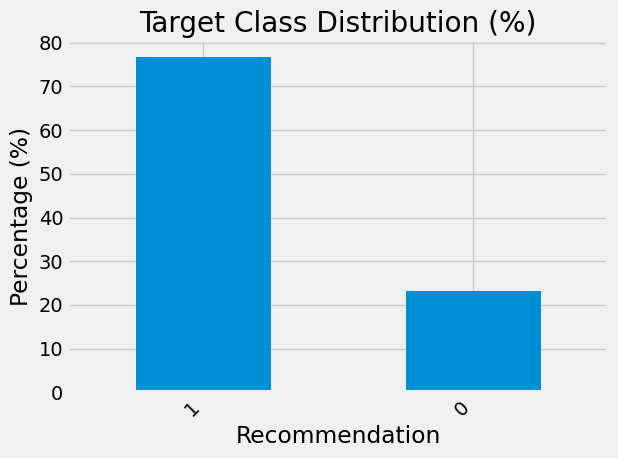

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

pct = (
    train_df['recommendation']
    .astype(str)
    .str.strip()
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .sort_values(ascending=False)
)

print(pct.round(2))

# Plot
plt.figure()
pct.plot(kind="bar")
plt.ylabel("Percentage (%)")
plt.xlabel('Recommendation')
plt.title("Target Class Distribution (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
test_df.groupby('recommendation')['recommendation'].value_counts()

recommendation
0    2875
1    9885
Name: count, dtype: int64

In [22]:
X_train = train_df.drop(columns=['GroupID', 'recommendation'])
y_train = train_df['recommendation']

X_test = test_df.drop(columns=['GroupID', 'recommendation'])
y_test = test_df['recommendation']

In [23]:
X_train.head()

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellowing of colors,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust,age,gender,duration,severity
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [24]:
y_train.head()

1    1
2    0
3    1
4    0
5    0
Name: recommendation, dtype: int64

In [25]:
X_test.head()

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellowing of colors,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust,age,gender,duration,severity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,0
13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,1,0,0
15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
17,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1


In [26]:
y_test.head()

0     1
13    0
14    0
15    0
17    1
Name: recommendation, dtype: int64

In [27]:
rf = RandomForestClassifier(n_estimators=31,
                            # class_weight='balanced',
                            random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f} (weighted)")
print(f"Recall   : {rec_rf:.4f} (weighted)")
print(f"F1-score : {f1_rf:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=4, zero_division=0))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Accuracy : 0.9368
Precision: 0.9394 (weighted)
Recall   : 0.9368 (weighted)
F1-score : 0.9376 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.8318    0.9016    0.8653      2875
           1     0.9707    0.9470    0.9587      9885

    accuracy                         0.9368     12760
   macro avg     0.9012    0.9243    0.9120     12760
weighted avg     0.9394    0.9368    0.9376     12760



In [28]:
knn = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="weighted", zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, average="weighted", zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, average="weighted", zero_division=0)

print(f"Accuracy : {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f} (weighted)")
print(f"Recall   : {rec_knn:.4f} (weighted)")
print(f"F1-score : {f1_knn:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_knn, digits=4, zero_division=0))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Accuracy : 0.9274
Precision: 0.9325 (weighted)
Recall   : 0.9274 (weighted)
F1-score : 0.9290 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.7994    0.9050    0.8489      2875
           1     0.9713    0.9339    0.9522      9885

    accuracy                         0.9274     12760
   macro avg     0.8853    0.9195    0.9006     12760
weighted avg     0.9325    0.9274    0.9290     12760



In [29]:
dt = DecisionTreeClassifier(max_depth=159, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average="weighted", zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, average="weighted", zero_division=0)
f1_dt  = f1_score(y_test, y_pred_dt, average="weighted", zero_division=0)

print(f"Accuracy : {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f} (weighted)")
print(f"Recall   : {rec_dt:.4f} (weighted)")
print(f"F1-score : {f1_dt:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_dt, digits=4, zero_division=0))


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Accuracy : 0.9277
Precision: 0.9301 (weighted)
Recall   : 0.9277 (weighted)
F1-score : 0.9286 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.8169    0.8755    0.8452      2875
           1     0.9630    0.9429    0.9529      9885

    accuracy                         0.9277     12760
   macro avg     0.8900    0.9092    0.8990     12760
weighted avg     0.9301    0.9277    0.9286     12760



/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [30]:
xgb = XGBClassifier(
    eval_metric='aucpr',
    scale_pos_weight=3.29,
    n_estimators=800,
    learning_rate=0.1,
    max_depth=15,
    min_child_weight=4,
    # subsample=0.8,
    # colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, average="weighted", zero_division=0)
rec_xgb  = recall_score(y_test, y_pred_xgb, average="weighted", zero_division=0)
f1_xgb   = f1_score(y_test, y_pred_xgb, average="weighted", zero_division=0)

print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f} (weighted)")
print(f"Recall   : {rec_xgb:.4f} (weighted)")
print(f"F1-score : {f1_xgb:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4, zero_division=0))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/xgboost/data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/xgboost/data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


Accuracy : 0.9375
Precision: 0.9366 (weighted)
Recall   : 0.9375 (weighted)
F1-score : 0.9368 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.8874    0.8278    0.8566      2875
           1     0.9509    0.9694    0.9601      9885

    accuracy                         0.9375     12760
   macro avg     0.9191    0.8986    0.9083     12760
weighted avg     0.9366    0.9375    0.9368     12760



In [31]:
lgbm = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    # class_weight='balanced',
    n_estimators=500,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.5,
    colsample_bytree=0.5,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

acc_lgbm  = accuracy_score(y_test, y_pred_lgbm)
prec_lgbm = precision_score(y_test, y_pred_lgbm, average="weighted", zero_division=0)
rec_lgbm  = recall_score(y_test, y_pred_lgbm, average="weighted", zero_division=0)
f1_lgbm   = f1_score(y_test, y_pred_lgbm, average="weighted", zero_division=0)

print(f"Accuracy : {acc_lgbm:.4f}")
print(f"Precision: {prec_lgbm:.4f} (weighted)")
print(f"Recall   : {rec_lgbm:.4f} (weighted)")
print(f"F1-score : {f1_lgbm:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm, digits=4, zero_division=0))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 39507, number of negative: 11996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2699
[LightGBM] [Info] Number of data points in the train set: 51503, number of used features: 1348
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.767082 -> initscore=1.191905
[LightGBM] [Info] Start training from score 1.191905
Accuracy : 0.9499
Precision: 0.9503 (weighted)
Recall   : 0.9499 (weighted)
F1-score : 0.9501 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.8821    0.8977    0.8898      2875
           1     0.9701    0.9651    0.9676      9885

    accuracy                         0.9499     12760
   macro avg   

In [32]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('knn', knn),
        ('dt', dt),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft',
    weights=[1, 0.5, 1, 2.5, 2.5]
)

voting_clf.fit(X_train, y_train)

y_pred_voting = voting_clf.predict(X_test)

acc_voting  = accuracy_score(y_test, y_pred_voting)
prec_voting = precision_score(y_test, y_pred_voting, average="weighted", zero_division=0)
rec_voting  = recall_score(y_test, y_pred_voting, average="weighted", zero_division=0)
f1_voting  = f1_score(y_test, y_pred_voting, average="weighted", zero_division=0)

print(f"Accuracy : {acc_voting:.4f}")
print(f"Precision: {prec_voting:.4f} (weighted)")
print(f"Recall   : {rec_voting:.4f} (weighted)")
print(f"F1-score : {f1_voting:.4f} (weighted)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_voting, digits=4, zero_division=0))

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/xgboost/data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 39507, number of negative: 11996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2699
[LightGBM] [Info] Number of data points in the train set: 51503, number of used features: 1348
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.767082 -> initscore=1.191905
[LightGBM] [Info] Start training from score 1.191905


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/utils/validation.py:785: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/xgboost/data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


Accuracy : 0.9462
Precision: 0.9464 (weighted)
Recall   : 0.9462 (weighted)
F1-score : 0.9463 (weighted)

Classification Report:
              precision    recall  f1-score   support

           0     0.8775    0.8849    0.8812      2875
           1     0.9664    0.9641    0.9653      9885

    accuracy                         0.9462     12760
   macro avg     0.9220    0.9245    0.9232     12760
weighted avg     0.9464    0.9462    0.9463     12760



In [55]:
from sklearn.metrics import roc_auc_score, average_precision_score
roc_auc_score = roc_auc_score(y_test, y_pred_voting)
average_precision_score = average_precision_score(y_test, y_pred_voting)

In [56]:
roc_auc_score

0.9244782828616042

In [57]:
average_precision_score

0.9595472181274953

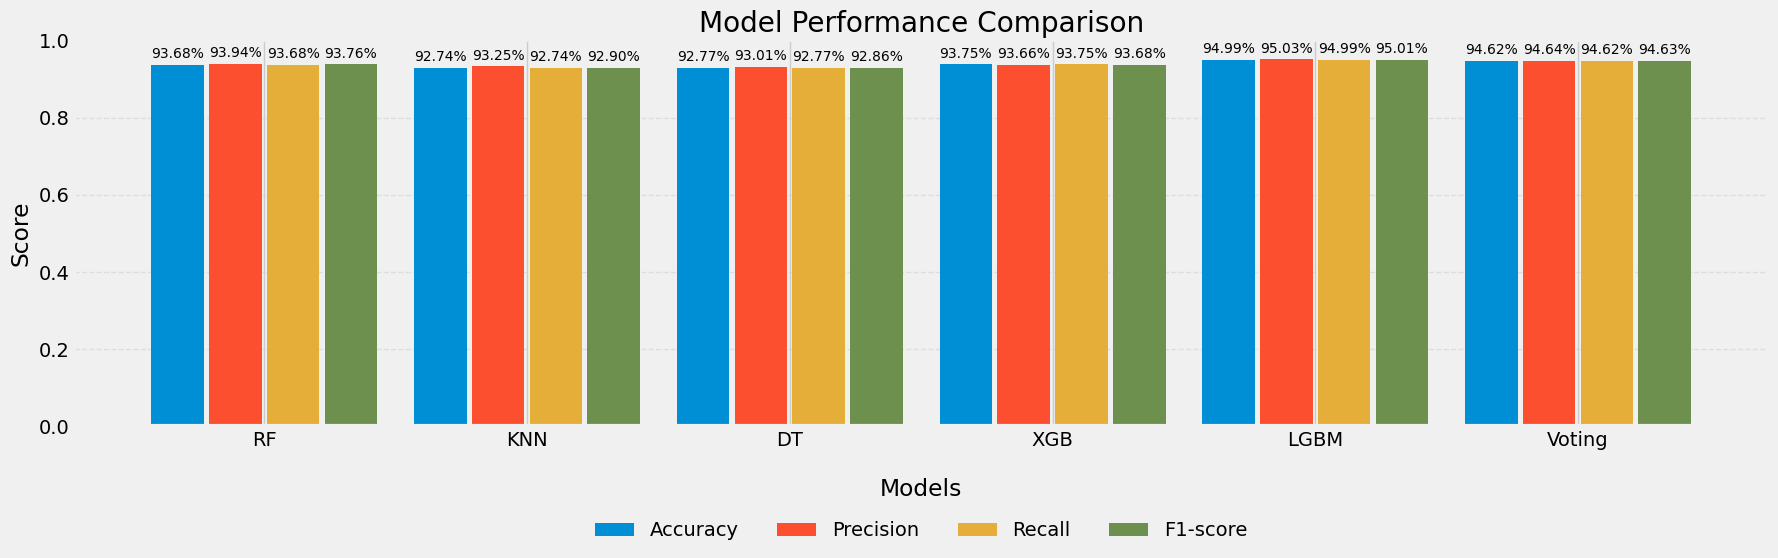

In [33]:
models = ['RF', 'KNN', 'DT', 'XGB', 'LGBM', 'Voting']

accuracy  = [acc_rf, acc_knn, acc_dt, acc_xgb, acc_lgbm, acc_voting]
precision = [prec_rf, prec_knn, prec_dt, prec_xgb, prec_lgbm, prec_voting]
recall    = [rec_rf, rec_knn, rec_dt, rec_xgb, rec_lgbm, rec_voting]
f1_score_ = [f1_rf, f1_knn, f1_dt, f1_xgb, f1_lgbm, f1_voting]

x = np.arange(len(models))
width = 0.2
gap = 0.02

offsets = [
    -1.5*(width + gap),
    -0.5*(width + gap),
     0.5*(width + gap),
     1.5*(width + gap)
]

plt.figure(figsize=(18, 6))

bars_acc = plt.bar(x + offsets[0], accuracy,  width, label='Accuracy')
bars_prec = plt.bar(x + offsets[1], precision, width, label='Precision')
bars_rec = plt.bar(x + offsets[2], recall,    width, label='Recall')
bars_f1 = plt.bar(x + offsets[3], f1_score_, width, label='F1-score')

plt.xlabel("Models", labelpad=20)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=False
)

def add_percentage(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height*100:.2f}%",
            ha='center',
            va='bottom',
            fontsize=10
        )

add_percentage(bars_acc)
add_percentage(bars_prec)
add_percentage(bars_rec)
add_percentage(bars_f1)

plt.tight_layout()
plt.show()


In [34]:
artifacts = {
    "model": voting_clf,
    "symptom_mlb": mlb,
    # "feature_order": list(X_train.columns)
}

joblib.dump(artifacts, "/teamspace/studios/this_studio/model/triage_artifacts.joblib", compress=3)
print("Saved triage_artifacts.joblib")


Saved triage_artifacts.joblib


In [35]:
artifacts = joblib.load('/teamspace/studios/this_studio/model/triage_artifacts.joblib')
voting_clf = artifacts['model']
mlb = artifacts['symptom_mlb']

In [36]:
# useage example
data = {
    'Symptoms': 'fever, headache, cough, Breath discomfort, problem focusing eyes',
    'Gender': 'Male',
    'Age': 'above 45 years',
    'Severity': 'Moderate',
    'Duration': 'Greater than 3 days'
}

In [37]:
df = pd.DataFrame([data])
df

,Symptoms,Gender,Age,Severity,Duration
0,"fever, headache, cough, Breath discomfort, pro...",Male,above 45 years,Moderate,Greater than 3 days


In [38]:
df["Symptoms_list"] = df["Symptoms"].apply(split_and_clean_symptoms)
enc_sym_data = mlb.transform(df["Symptoms_list"])


In [39]:
enc_sym_dense = enc_sym_data.toarray()


In [ ]:
symptom_df = pd.DataFrame(
    enc_sym_dense,
    columns=mlb.classes_
)

In [41]:
symptom_df

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellow eye,yellow mucus from nose,yellow skin,yellow sore center,yellowing of colors,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
symptom_df['breath discomfort']

0    1
Name: breath discomfort, dtype: int64

In [43]:
df['age'] = mapping_age(df['Age'])
df['gender'] = mapping_gen(df['Gender'])
df['duration'] = mapping_dur(df['Duration'])
df['severity'] = mapping_sev(df['Severity'])

In [44]:
df

,Symptoms,Gender,Age,Severity,Duration,Symptoms_list,age,gender,duration,severity
0,"fever, headache, cough, Breath discomfort, pro...",Male,above 45 years,Moderate,Greater than 3 days,"[fever, breath discomfort, cough, problem focu...",3,1,1,1


In [45]:
df_encode_data = pd.concat([symptom_df, df.drop(columns=['Symptoms', 'Age', 'Gender', 'Duration', 'Severity', 'Symptoms_list'])], axis=1)

In [46]:
df_encode_data

,a cauliflower like shape caused by a few warts close together,a feeling of warmth on the affected leg,a feeling of weakness,a gritty feeling in eyes,a high temperature does not go away,a pause in breathing,a pause in breathing in babies,a stiff neck,a white,abdominal bloating,...,yellowing of colors,yellowing of the whites of the eyes,yellowing skin,yellowish coloration skin white eye,yellowish skin,yellowish skin crust,age,gender,duration,severity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,1,1,1


In [47]:
voting_clf.predict(df_encode_data)[0]

1

In [48]:
proba = voting_clf.predict_proba(df_encode_data)
proba


array([[1.32586964e-04, 9.99867413e-01]])

In [49]:
conf = proba[0][1]*100

In [50]:
print(f'confidence score {conf:.2f}%')

confidence score 99.99%


In [51]:
print(voting_clf.classes_)


[0 1]
